# Bilbiotecas necessárias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import signal

# Análise de FM no domínio do tempo

Vetor do tempo de zero a 40ms,, com amostragem de 10us

In [2]:
Tstart=0
Tstop=40e-3
Tstep=10e-6

t=np.arange(Tstart,Tstop,Tstep)

$m(t)=A_mcos(2 \pi f_mt)$  -> Sinal de Informação

In [3]:
Am=5    # amplitude da info
fm=100  # frequencia da info
mt=Am*np.cos(2*math.pi*fm*t)  # mensagem

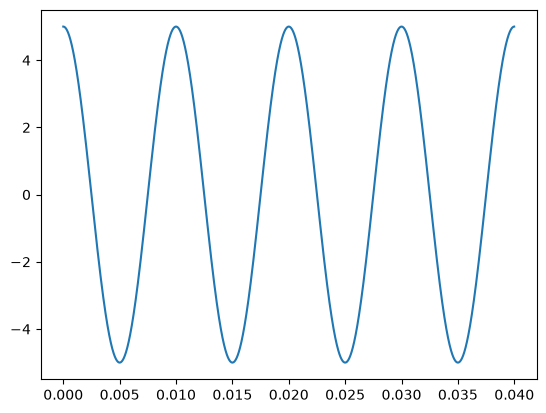

In [4]:
plt.plot(t,mt)

**Portadora** -> $c(t)=A_ccos(2 \pi f_ct)$

In [5]:
Ac=5      # amplitude da portadora
fc=1000   # frequencia da portadora
ct=Ac*np.cos(2*math.pi*fc*t)

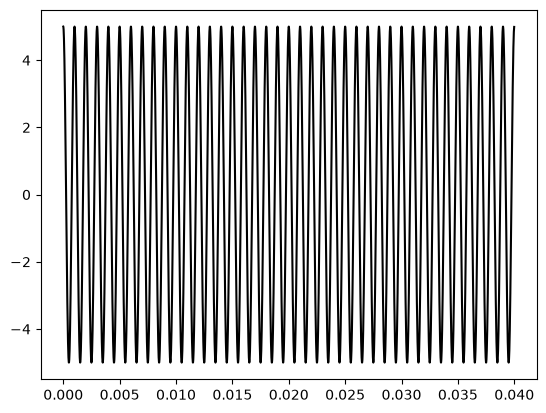

In [6]:
plt.plot(t,ct,'k')

Sinal FM $s(t)=A_c \cos\left( 2 \pi f_c t+ k_f \int_0^t m(\tau) d\tau \right) $.

OU $s(t)=A_c \cos\left( 2 \pi f_c t+\beta \sin(2\pi f_m t) \right)$, where $\beta = \frac{k_f A_m}{f_m}$.

In [7]:
Kf=100      # sensibilidade em frequencia (Hz/volt)
B= Kf*Am/fm # indice de modulação FM (beta)
st=Ac*np.cos(2*math.pi*fc*t + B*np.sin(2*math.pi*fm*t))   # sinal modulado

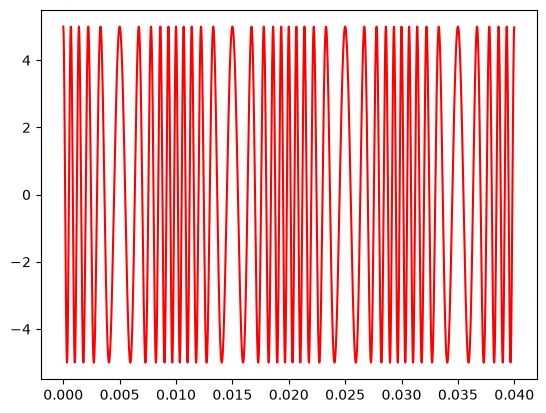

In [8]:
plt.plot(t,st,'r')

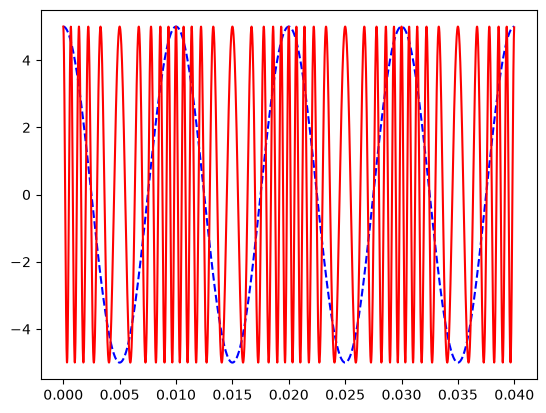

In [9]:
plt.plot(t,mt,'b--')
plt.plot(t,st,'r')

Variando a amplitude do sinal de informação $A_m$.

O que será que acontece com o sinal modulado?

Text(0.5, 1.0, '$A_m =1$')

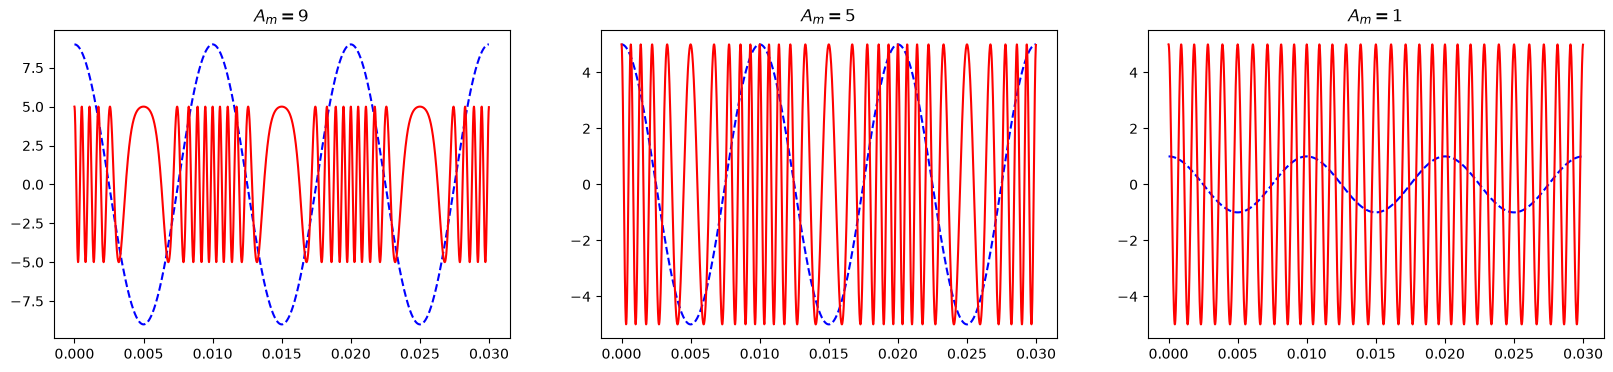

In [10]:
# modificando as amplitudes do sinal de informação
Am1=9
Am2=5
Am3=1

fm=100
Ac=5
fc=1000
Kf=100

Tstart=0
Tstop=3e-2
Tstep=1e-5
t=np.arange(Tstart,Tstop,Tstep)


f = plt.figure(figsize=(20,4))
ax1 = f.add_subplot(131)
ax2 = f.add_subplot(132)
ax3 = f.add_subplot(133)

ct=Ac*np.cos(2*math.pi*fc*t)    # portadora

mt1=Am1*np.cos(2*math.pi*fm*t)    # sinal de informação
B1= Kf*Am1/fm     # beta 1
st1=Ac*np.cos(2*math.pi*fc*t + B1*np.sin(2*math.pi*fm*t)) # sinal FM

mt2=Am2*np.cos(2*math.pi*fm*t)
B2= Kf*Am2/fm
st2=Ac*np.cos(2*math.pi*fc*t + B2*np.sin(2*math.pi*fm*t))


mt3=Am3*np.cos(2*math.pi*fm*t)
B3= Kf*Am3/fm
st3=Ac*np.cos(2*math.pi*fc*t + B3*np.sin(2*math.pi*fm*t))

ax1.plot(t,mt1,'b--')
ax1.plot(t,st1,'r')
ax1.set_title('$A_m ={}$'.format(Am1))

ax2.plot(t,mt2,'b--')
ax2.plot(t,st2,'r')
ax2.set_title('$A_m ={}$'.format(Am2))

ax3.plot(t,mt3,'b--')
ax3.plot(t,st3,'r')
ax3.set_title('$A_m ={}$'.format(Am3))

A amplitude do sinal, 𝐴𝑚,  afeta o desvio em frequência  $\Delta f= k_f A_m$. As amplitudes de $c(t)$ e $s(t)$ permanecem inalteradas (±5𝑉).

# FM no dominio da frequência

Como pode ser observado, o espectro do sinal s(t) consiste na soma de deltas em números inteiros múltiplos de $f_m$  $$S_{FM}(f) = \sum_{n=-\infty}^{\infty}J_n(\beta)\delta(f-nf_m)$$

onde $J_n(\beta)$ é o valor dado pela função de Bessel de ordem n.

/tmp/ipykernel_14876/2575590922.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax8.legend()


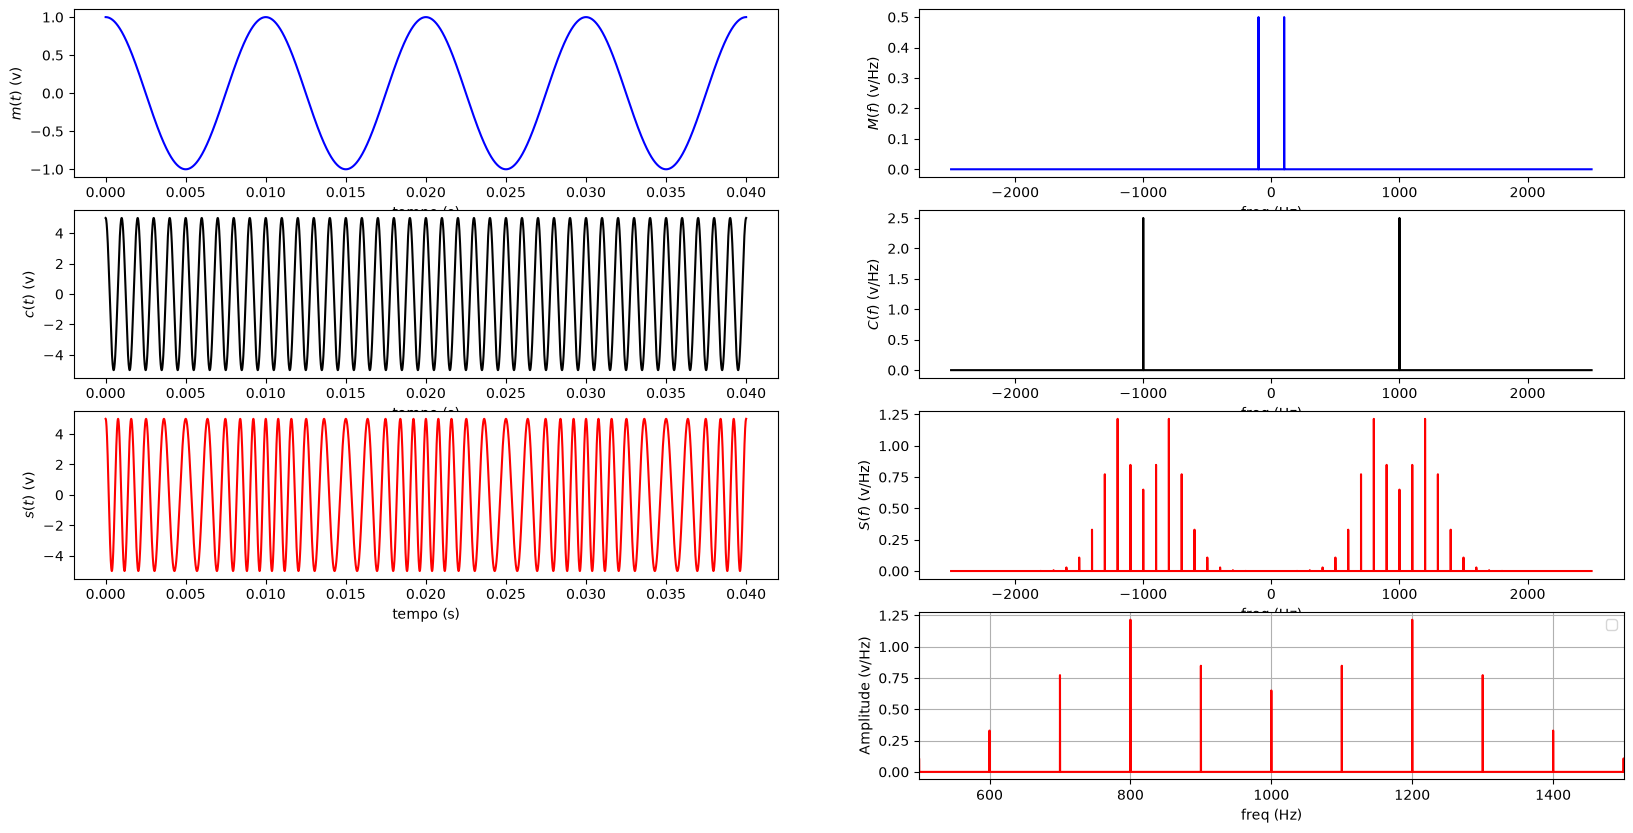

In [11]:
Am=1      # amplitude do sinal de info
fm=100    # frequencia do sinal de info
Ac=5      # amplitude da portadora
fc=1000   # frequencia da portadora
Kf=300    # sensibilidade do modulador


Tstart=0
Tstop=4/fm
Tstep=0.0001/fm

t=np.arange(Tstart,Tstop,Tstep)   # tempo
mt=Am*np.cos(2*math.pi*fm*t)      # info
ct=Ac*np.cos(2*math.pi*fc*t)      # portadora
B= Kf*Am/fm                       # indice de modulação FM (beta)
st=Ac*np.cos(2*math.pi*fc*t + B*np.sin(2*math.pi*fm*t)) # sinal modulado

f = plt.figure(figsize=(20,10))
ax1 = f.add_subplot(421)
ax2 = f.add_subplot(422)
ax3 = f.add_subplot(423)
ax4 = f.add_subplot(424)
ax5 = f.add_subplot(425)
ax6 = f.add_subplot(426)
#ax7 = f.add_subplot(427)   eliminando o gráfico de propósito
ax8 = f.add_subplot(428)



ax1.plot(t,mt,'b')
ax1.set_xlabel('tempo (s)')
ax1.set_ylabel('$m(t)$ (v)')


ax3.plot(t,ct,'k')
ax3.set_xlabel('tempo (s)')
ax3.set_ylabel('$c(t)$ (v)')

ax5.plot(t,st,'r')
ax5.set_xlabel('tempo (s)')
ax5.set_ylabel('$s(t)$ (v)')


Tstart=0
Tstop=10000/fc
Tstep=0.2/fc

t=np.arange(Tstart,Tstop,Tstep)
N=len(t)
mt=Am*np.cos(2*math.pi*fm*t) # info
ct=Ac*np.cos(2*math.pi*fc*t) # portadora
B= Kf*Am/fm     # indice de modulacao
st=Ac*np.cos(2*math.pi*fc*t + B*np.sin(2*math.pi*fm*t)) # sinal FM

Mf = np.abs(np.fft.fft(mt))
freqs = np.fft.fftfreq(mt.size, Tstep)
idx = np.argsort(freqs)
freqs=freqs[idx]
Mf=Mf[idx]/N
ax2.plot(freqs, Mf,'b')
ax2.set_xlabel('freq (Hz)')
ax2.set_ylabel('$M(f)$ (v/Hz)')


Cf = np.abs(np.fft.fft(ct))
freqs = np.fft.fftfreq(ct.size, Tstep)
idx = np.argsort(freqs)
freqs=freqs[idx]
Cf=Cf[idx]/N
ax4.plot(freqs, Cf,'k')
ax4.set_xlabel('freq (Hz)')
ax4.set_ylabel('$C(f)$ (v/Hz)')


Sf = np.abs(np.fft.fft(st))
freqs = np.fft.fftfreq(st.size, Tstep)
idx = np.argsort(freqs)
freqs=freqs[idx]
Sf=Sf[idx]/N
ax6.plot(freqs, Sf,'r')
ax6.set_xlabel('freq (Hz)')
ax6.set_ylabel('$S(f)$ (v/Hz)')

ax8.plot(freqs, Sf,'r')
ax8.set_xlabel('freq (Hz)')
ax8.set_ylabel('Amplitude (v/Hz)')
xmin, xmax = ax8.get_xlim()
df=xmax-fc;
if (fc+5*fm < xmax) and (fc-5*fm > 0):
   ax8.set_xlim([fc-5*fm, fc+5*fm])
elif (fc-5*fm > 0):
   ax8.set_xlim([fc-5*fm, xmax])
elif (fc+5*fm < xmax):
   ax8.set_xlim([0, fc+5*fm])
else:
  ax8.set_xlim([0, xmax])
ax8.grid()
ax8.legend()

# Parte 1 — Parâmetros individualizados

A partir daqui, os parâmetros da simulação não são mais fixos: eles dependem da sua matrícula. Isso significa que o seu gráfico, o seu β e a sua resposta sobre banda larga/estreita serão diferentes dos do colega ao lado.
Rode a célula abaixo substituindo `RA` pela sua matrícula.

In [12]:
RA = 202210505875  # <-- substitua pela sua matrícula/RA

rng = np.random.default_rng(RA)

Am = int(rng.integers(2, 9))                     # amplitude do sinal de informação (V)
fm = int(rng.choice([80, 120, 150, 180, 220]))    # frequência do sinal de informação (Hz)
Kf = int(rng.integers(150, 450))                  # sensibilidade do modulador (Hz/V)
Ac = 5                                            # amplitude da portadora (mantida fixa)
fc = 1000                                         # frequência da portadora (mantida fixa)

print("Seus parâmetros individualizados:")
print(f"Am = {Am} V")
print(f"fm = {fm} Hz")
print(f"Kf = {Kf} Hz/V")

Seus parâmetros individualizados:
Am = 6 V
fm = 220 Hz
Kf = 172 Hz/V


### Antes de rodar qualquer código de plotagem...

Calcule **manualmente** (papel, calculadora ou uma célula simples só com contas — sem gráfico ainda) os seguintes valores para os *seus* parâmetros:

1. O desvio de frequência: Δf = Kf · Am
2. O índice de modulação: β = Δf / fm
3. Classificação: FM de faixa estreita (β ≤ 0,2), faixa larga (β > 2), ou faixa intermediária?

Anote esses valores na célula de texto abaixo **antes** de gerar o gráfico. Depois você vai comparar com o que o código calcular.

_Δf = Kf · Am = 172 · 6 = 1032 Hz_

_β = Δf / fm = 1032 / 220 = 4,691_ 

_é uma faixa larga._

### Agora gere o gráfico

Adapte o código da célula "FM no domínio da frequência"  para usar os seus `Am`, `fm`, `Ac`, `fc` e `Kf` individualizados. Confirme que o β calculado pelo código bate com o seu cálculo manual.

In [13]:
Am = 6       # amplitude do sinal de informação (V)
fm = 220     # frequência do sinal de informação (Hz)

Ac = 5       # amplitude da portadora (V)
fc = 1000    # frequência da portadora (Hz)

Kf = 172     # sensibilidade do modulador (Hz/V)


# ============================================================
# Parâmetros da modulação
# ============================================================

B = Kf*Am/fm                    # índice de modulação (beta)
Delta_f = Kf*Am                 # desvio máximo de frequência


print(f"Índice de modulação β = {B:.2f}")
print(f"Desvio máximo Δf = {Delta_f:.0f} Hz")


# ============================================================
# Sinais para visualização no tempo
# ============================================================

Tstart = 0
Tstop = 4/fm                    # 4 períodos do sinal de informação
Tstep = 0.0001/fm

t = np.arange(Tstart, Tstop, Tstep)

mt = Am*np.cos(2*np.pi*fm*t)    # sinal de informação

ct = Ac*np.cos(2*np.pi*fc*t)    # portadora

st = Ac*np.cos(
    2*np.pi*fc*t +
    B*np.sin(2*np.pi*fm*t)
)                                # sinal FM


# ============================================================
# Sinais para análise em frequência
# ============================================================

Tstart_fft = 0
Tstop_fft = 10000/fc
Tstep_fft = 0.2/fc

t_fft = np.arange(Tstart_fft, Tstop_fft, Tstep_fft)

N = len(t_fft)

mt_fft = Am*np.cos(2*np.pi*fm*t_fft)

ct_fft = Ac*np.cos(2*np.pi*fc*t_fft)

st_fft = Ac*np.cos(
    2*np.pi*fc*t_fft +
    B*np.sin(2*np.pi*fm*t_fft)
)

Índice de modulação β = 4.69
Desvio máximo Δf = 1032 Hz


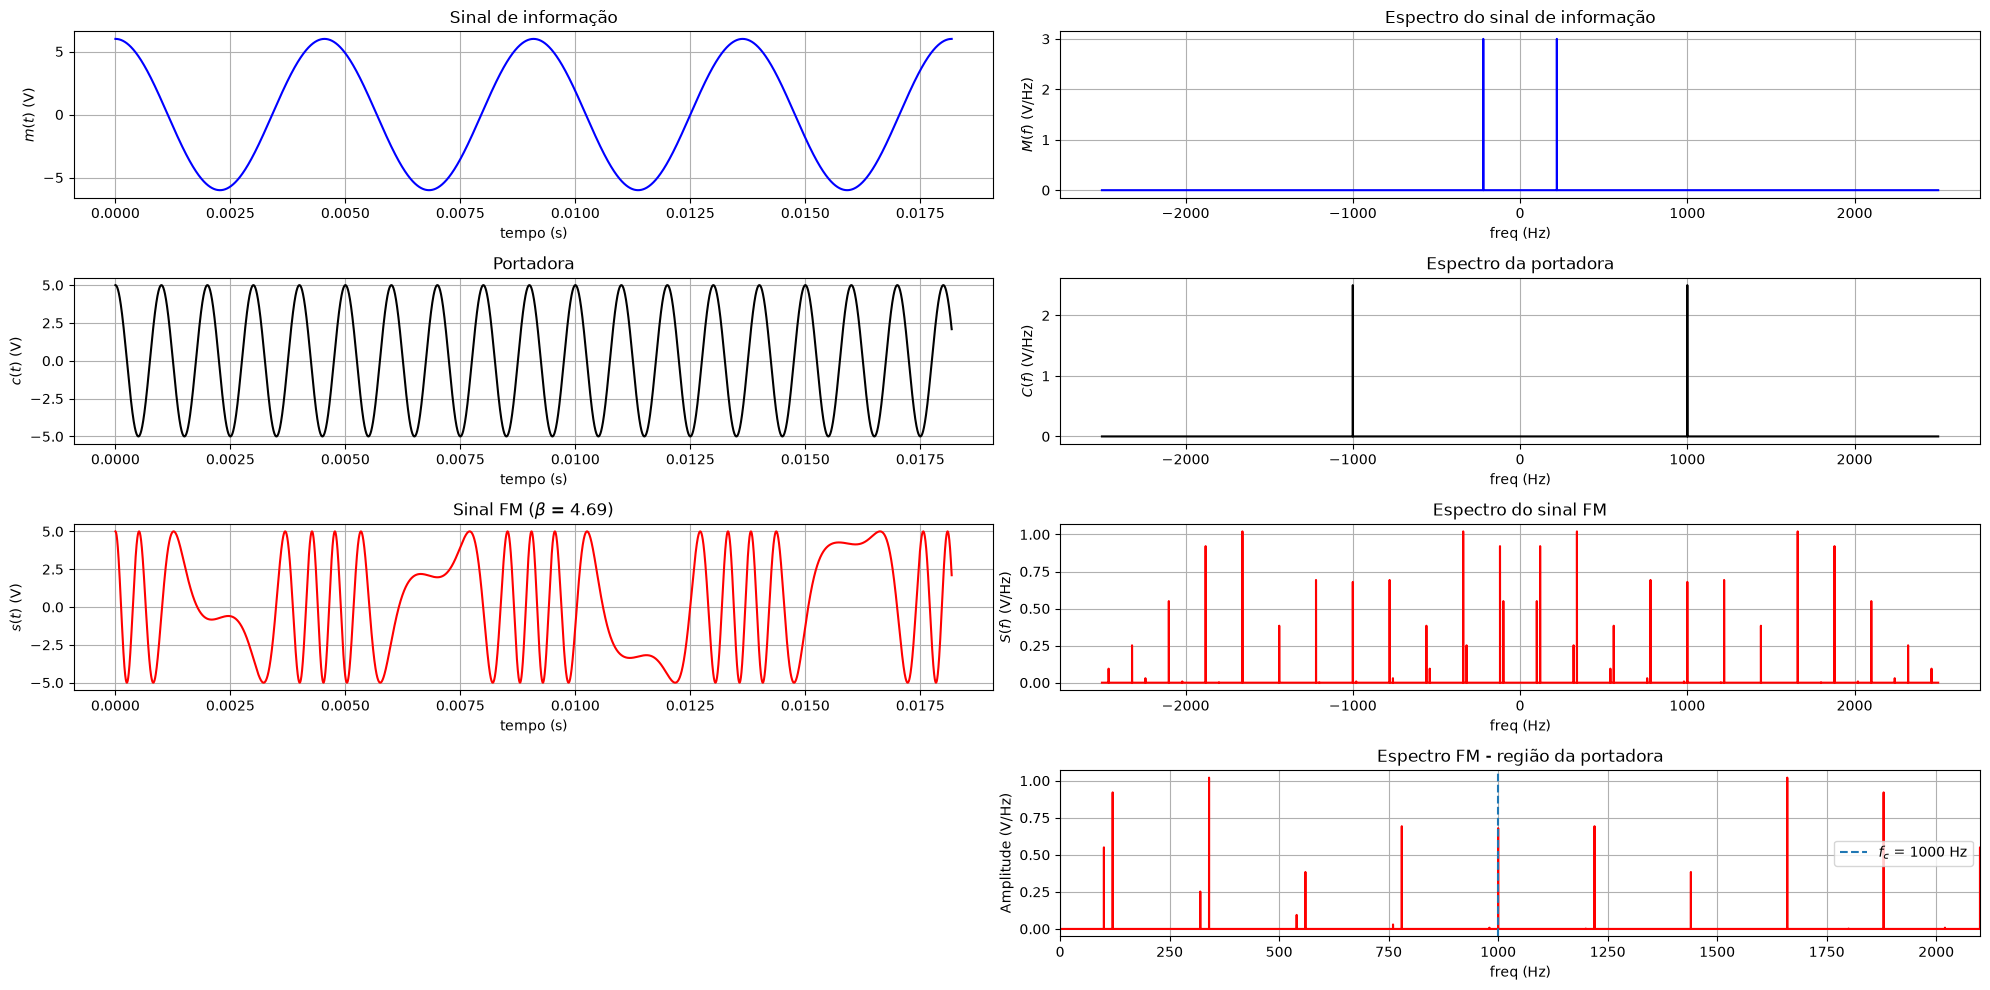

In [14]:
f = plt.figure(figsize=(20, 10))

ax1 = f.add_subplot(421)
ax2 = f.add_subplot(422)

ax3 = f.add_subplot(423)
ax4 = f.add_subplot(424)

ax5 = f.add_subplot(425)
ax6 = f.add_subplot(426)

# ax7 = f.add_subplot(427)   # gráfico eliminado

ax8 = f.add_subplot(428)


# ============================================================
# Sinal de informação - tempo
# ============================================================

ax1.plot(t, mt, 'b')

ax1.set_xlabel('tempo (s)')
ax1.set_ylabel('$m(t)$ (V)')
ax1.set_title('Sinal de informação')

ax1.grid()


# ============================================================
# Sinal de informação - frequência
# ============================================================

Mf = np.abs(np.fft.fft(mt_fft))

freqs_m = np.fft.fftfreq(N, Tstep_fft)

idx = np.argsort(freqs_m)

freqs_m = freqs_m[idx]
Mf = Mf[idx] / N

ax2.plot(freqs_m, Mf, 'b')

ax2.set_xlabel('freq (Hz)')
ax2.set_ylabel('$M(f)$ (V/Hz)')
ax2.set_title('Espectro do sinal de informação')

ax2.grid()


# ============================================================
# Portadora - tempo
# ============================================================

ax3.plot(t, ct, 'k')

ax3.set_xlabel('tempo (s)')
ax3.set_ylabel('$c(t)$ (V)')
ax3.set_title('Portadora')

ax3.grid()


# ============================================================
# Portadora - frequência
# ============================================================

Cf = np.abs(np.fft.fft(ct_fft))

freqs_c = np.fft.fftfreq(N, Tstep_fft)

idx = np.argsort(freqs_c)

freqs_c = freqs_c[idx]
Cf = Cf[idx] / N

ax4.plot(freqs_c, Cf, 'k')

ax4.set_xlabel('freq (Hz)')
ax4.set_ylabel('$C(f)$ (V/Hz)')
ax4.set_title('Espectro da portadora')

ax4.grid()


# ============================================================
# Sinal FM - tempo
# ============================================================

ax5.plot(t, st, 'r')

ax5.set_xlabel('tempo (s)')
ax5.set_ylabel('$s(t)$ (V)')
ax5.set_title(f'Sinal FM ($\\beta$ = {B:.2f})')

ax5.grid()


# ============================================================
# Sinal FM - frequência
# ============================================================

Sf = np.abs(np.fft.fft(st_fft))

freqs_s = np.fft.fftfreq(N, Tstep_fft)

idx = np.argsort(freqs_s)

freqs_s = freqs_s[idx]
Sf = Sf[idx] / N

ax6.plot(freqs_s, Sf, 'r')

ax6.set_xlabel('freq (Hz)')
ax6.set_ylabel('$S(f)$ (V/Hz)')
ax6.set_title('Espectro do sinal FM')

ax6.grid()


# ============================================================
# Espectro FM com zoom
# ============================================================

ax8.plot(freqs_s, Sf, 'r')

ax8.set_xlabel('freq (Hz)')
ax8.set_ylabel('Amplitude (V/Hz)')
ax8.set_title('Espectro FM - região da portadora')

ax8.grid()


# ============================================================
# Limites do gráfico em torno da portadora
# ============================================================

f_min = max(0, fc - 5*fm)
f_max = fc + 5*fm

ax8.set_xlim([f_min, f_max])


# Linha indicando a frequência da portadora

ax8.axvline(
    fc,
    linestyle='--',
    label=f'$f_c$ = {fc} Hz'
)

ax8.legend()


plt.tight_layout()
plt.show()

In [15]:
Delta_f = Kf * Am
f_min = fc - Delta_f
f_max = fc + Delta_f

print(f"β = {B:.2f}")
print(f"Δf = {Delta_f:.0f} Hz")
print(f"Frequência instantânea mínima = {f_min:.0f} Hz")
print(f"Frequência instantânea máxima = {f_max:.0f} Hz")

β = 4.69
Δf = 1032 Hz
Frequência instantânea mínima = -32 Hz
Frequência instantânea máxima = 2032 Hz


# Parte 2 — E se...? (investigando os limites do modelo)

Usando o **seu** conjunto de parâmetros (Am, fm, Kf) da Parte 1 como ponto de partida, responda às perguntas abaixo. Para cada uma, mostre o código/gráfico que usou e depois explique o resultado **usando a teoria da Aula 3** — não basta descrever o que o gráfico mostra.

**1) Dobrando fm com Δf fixo**

Se você dobrar fm mas ajustar Kf de forma a manter Δf = Kf·Am constante, o que acontece com β? E com a largura de banda de Carson (BWFM = 2(Δf + fm))? O comportamento é o mesmo que dobrar Δf mantendo fm fixo? Mostre os dois casos lado a lado.

In [16]:
# ============================================================
# Parâmetros originais
# ============================================================

Am = 6
fm = 220
Ac = 5
fc = 1000
Kf = 172

Delta_f = Kf * Am
B = Delta_f / fm

BT = 2 * (Delta_f + fm)


# ============================================================
# Caso A: dobrar fm mantendo Delta_f constante
# ============================================================

fm_A = 2 * fm

Delta_f_A = Delta_f

Kf_A = Delta_f_A / Am

B_A = Delta_f_A / fm_A

BT_A = 2 * (Delta_f_A + fm_A)


# ============================================================
# Caso B: dobrar Delta_f mantendo fm constante
# ============================================================

fm_B = fm

Delta_f_B = 2 * Delta_f

Kf_B = Delta_f_B / Am

B_B = Delta_f_B / fm_B

BT_B = 2 * (Delta_f_B + fm_B)


# ============================================================
# Mostrar resultados
# ============================================================

print("Caso original:")
print(f"fm = {fm} Hz")
print(f"Kf = {Kf} Hz/V")
print(f"Delta_f = {Delta_f} Hz")
print(f"beta = {B:.2f}")
print(f"Carson = {BT} Hz")

print("\nCaso A - dobrando fm:")
print(f"fm = {fm_A} Hz")
print(f"Kf = {Kf_A:.0f} Hz/V")
print(f"Delta_f = {Delta_f_A} Hz")
print(f"beta = {B_A:.2f}")
print(f"Carson = {BT_A} Hz")

print("\nCaso B - dobrando Delta_f:")
print(f"fm = {fm_B} Hz")
print(f"Kf = {Kf_B:.0f} Hz/V")
print(f"Delta_f = {Delta_f_B} Hz")
print(f"beta = {B_B:.2f}")
print(f"Carson = {BT_B} Hz")

Caso original:
fm = 220 Hz
Kf = 172 Hz/V
Delta_f = 1032 Hz
beta = 4.69
Carson = 2504 Hz

Caso A - dobrando fm:
fm = 440 Hz
Kf = 172 Hz/V
Delta_f = 1032 Hz
beta = 2.35
Carson = 2944 Hz

Caso B - dobrando Delta_f:
fm = 220 Hz
Kf = 344 Hz/V
Delta_f = 2064 Hz
beta = 9.38
Carson = 4568 Hz


In [17]:
# ============================================================
# Caso A - fm dobrada, Delta_f constante
# ============================================================

Tstop_A = 4 / fm_A
Tstep_A = 0.0001 / fm_A

t_A = np.arange(0, Tstop_A, Tstep_A)

m_A = Am * np.cos(2*np.pi*fm_A*t_A)

s_A = Ac * np.cos(
    2*np.pi*fc*t_A +
    B_A*np.sin(2*np.pi*fm_A*t_A)
)


# ============================================================
# Caso B - Delta_f dobrado, fm constante
# ============================================================

Tstop_B = 4 / fm_B
Tstep_B = 0.0001 / fm_B

t_B = np.arange(0, Tstop_B, Tstep_B)

m_B = Am * np.cos(2*np.pi*fm_B*t_B)

s_B = Ac * np.cos(
    2*np.pi*fc*t_B +
    B_B*np.sin(2*np.pi*fm_B*t_B)
)

In [18]:
# ============================================================
# FFT - Caso A
# ============================================================

Tstep_fft = 0.2 / fc

Tstop_fft = 10000 / fc

t_fft = np.arange(0, Tstop_fft, Tstep_fft)

N = len(t_fft)


s_A_fft = Ac * np.cos(
    2*np.pi*fc*t_fft +
    B_A*np.sin(2*np.pi*fm_A*t_fft)
)

Sf_A = np.abs(np.fft.fft(s_A_fft))

freqs_A = np.fft.fftfreq(N, Tstep_fft)

idx_A = np.argsort(freqs_A)

freqs_A = freqs_A[idx_A]
Sf_A = Sf_A[idx_A] / N


# ============================================================
# FFT - Caso B
# ============================================================

s_B_fft = Ac * np.cos(
    2*np.pi*fc*t_fft +
    B_B*np.sin(2*np.pi*fm_B*t_fft)
)

Sf_B = np.abs(np.fft.fft(s_B_fft))

freqs_B = np.fft.fftfreq(N, Tstep_fft)

idx_B = np.argsort(freqs_B)

freqs_B = freqs_B[idx_B]
Sf_B = Sf_B[idx_B] / N

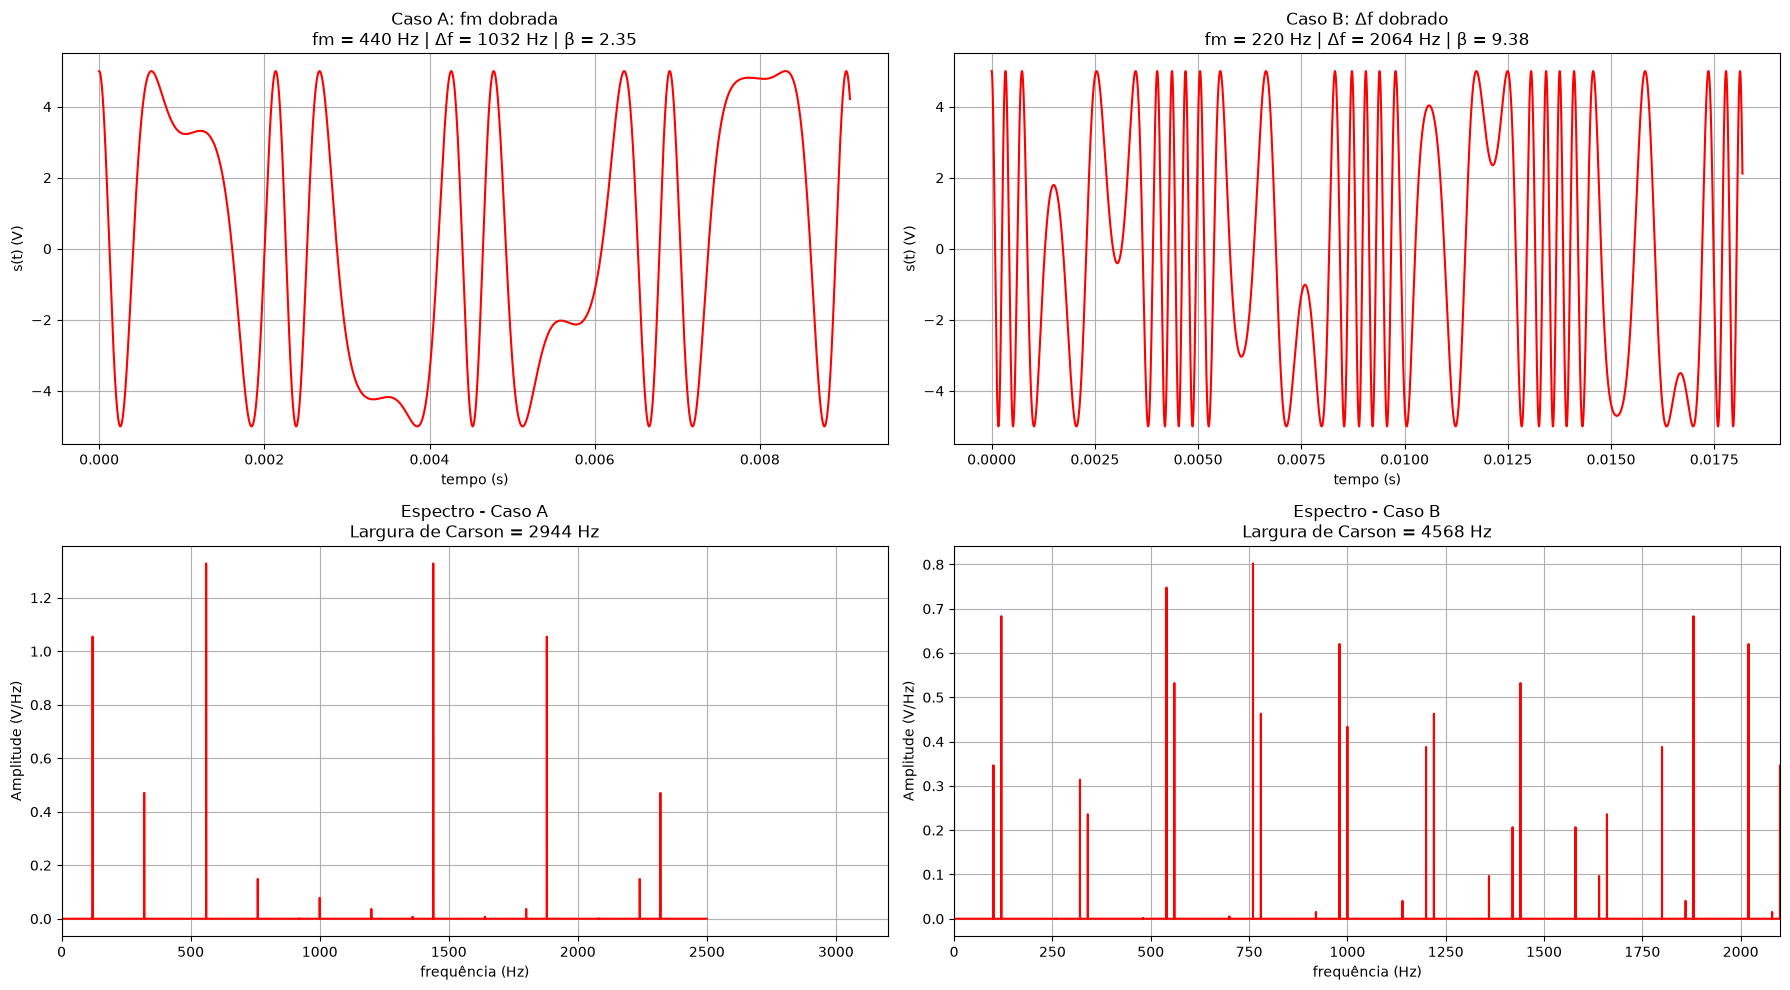

In [19]:
# ============================================================
# Comparação dos dois casos
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))


# ============================================================
# Caso A - tempo
# ============================================================

axes[0, 0].plot(t_A, s_A, 'r')

axes[0, 0].set_title(
    f'Caso A: fm dobrada\n'
    f'fm = {fm_A} Hz | Δf = {Delta_f_A} Hz | β = {B_A:.2f}'
)

axes[0, 0].set_xlabel('tempo (s)')
axes[0, 0].set_ylabel('s(t) (V)')

axes[0, 0].grid()


# ============================================================
# Caso B - tempo
# ============================================================

axes[0, 1].plot(t_B, s_B, 'r')

axes[0, 1].set_title(
    f'Caso B: Δf dobrado\n'
    f'fm = {fm_B} Hz | Δf = {Delta_f_B} Hz | β = {B_B:.2f}'
)

axes[0, 1].set_xlabel('tempo (s)')
axes[0, 1].set_ylabel('s(t) (V)')

axes[0, 1].grid()


# ============================================================
# Caso A - espectro
# ============================================================

axes[1, 0].plot(freqs_A, Sf_A, 'r')

axes[1, 0].set_title(
    f'Espectro - Caso A\n'
    f'Largura de Carson = {BT_A} Hz'
)

axes[1, 0].set_xlabel('frequência (Hz)')
axes[1, 0].set_ylabel('Amplitude (V/Hz)')

axes[1, 0].set_xlim([0, fc + 5*fm_A])

axes[1, 0].grid()


# ============================================================
# Caso B - espectro
# ============================================================

axes[1, 1].plot(freqs_B, Sf_B, 'r')

axes[1, 1].set_title(
    f'Espectro - Caso B\n'
    f'Largura de Carson = {BT_B} Hz'
)

axes[1, 1].set_xlabel('frequência (Hz)')
axes[1, 1].set_ylabel('Amplitude (V/Hz)')

axes[1, 1].set_xlim([0, fc + 5*fm_B])

axes[1, 1].grid()


plt.tight_layout()
plt.show()

_No primeiro caso, o desvio max da portadora continua o mesmo. Ou seja, ela ainda vai se deslocar em torno de 1kHz em uma faixa de aproximadamente 1032Hz para cada lado. A diferença é que a informação vai chegar ***duas vezes*** mais rapido. Simultâneamente, o beta caiu, resultando em amplitudes menores em bandas laterias. O conjunto resulta em um maior espaçamento entre as bandas laterais e um pequeno aumento na largura de banda._

_No segundo caso, o beta aumenta significativamente, o que gera em maiores amplitudes nas bandas laterais. Ou seja, o espaçamento se manteve, mas o número de bandas significativas aumentou, bem como a largura de banda._

**2) Anulando a portadora**

Ajuste Kf (mantendo Am e fm fixos) até que β fique próximo de 2,405 ou 5,52 — valores em que J₀(β) ≈ 0 (veja a Aula 3, slide "Conclusões sobre potência em FM"). Plote o espectro e observe a raia em fc (a portadora). O que aconteceu com ela? Isso significa que a informação foi perdida? Justifique.

In [20]:
# ============================================================
# Parâmetros fixos
# ============================================================

Am = 6          # amplitude do sinal de informação (V)
fm = 220        # frequência do sinal de informação (Hz)

Ac = 5          # amplitude da portadora (V)
fc = 1000       # frequência da portadora (Hz)


# ============================================================
# Caso 1 - primeiro zero de J0(beta)
# ============================================================

B1 = 2.405

Kf1 = B1 * fm / Am

Delta_f1 = Kf1 * Am


# ============================================================
# Caso 2 - segundo zero de J0(beta)
# ============================================================

B2 = 5.520

Kf2 = B2 * fm / Am

Delta_f2 = Kf2 * Am


# ============================================================
# Mostrar parâmetros
# ============================================================

print("Caso 1:")
print(f"β = {B1:.3f}")
print(f"Kf = {Kf1:.2f} Hz/V")
print(f"Δf = {Delta_f1:.2f} Hz")

print("\nCaso 2:")
print(f"β = {B2:.3f}")
print(f"Kf = {Kf2:.2f} Hz/V")
print(f"Δf = {Delta_f2:.2f} Hz")

Caso 1:
β = 2.405
Kf = 88.18 Hz/V
Δf = 529.10 Hz

Caso 2:
β = 5.520
Kf = 202.40 Hz/V
Δf = 1214.40 Hz


In [21]:
# ============================================================
# Janela para análise espectral
# ============================================================

Tstart = 0
Tstop = 10000/fc
Tstep = 0.2/fc

t = np.arange(Tstart, Tstop, Tstep)

N = len(t)


# ============================================================
# Caso 1 - beta = 2.405
# ============================================================

s1 = Ac * np.cos(
    2*np.pi*fc*t +
    B1*np.sin(2*np.pi*fm*t)
)


# ============================================================
# Caso 2 - beta = 5.520
# ============================================================

s2 = Ac * np.cos(
    2*np.pi*fc*t +
    B2*np.sin(2*np.pi*fm*t)
)


# ============================================================
# FFT - Caso 1
# ============================================================

S1 = np.abs(np.fft.fft(s1))

freqs1 = np.fft.fftfreq(N, Tstep)

idx1 = np.argsort(freqs1)

freqs1 = freqs1[idx1]
S1 = S1[idx1] / N


# ============================================================
# FFT - Caso 2
# ============================================================

S2 = np.abs(np.fft.fft(s2))

freqs2 = np.fft.fftfreq(N, Tstep)

idx2 = np.argsort(freqs2)

freqs2 = freqs2[idx2]
S2 = S2[idx2] / N

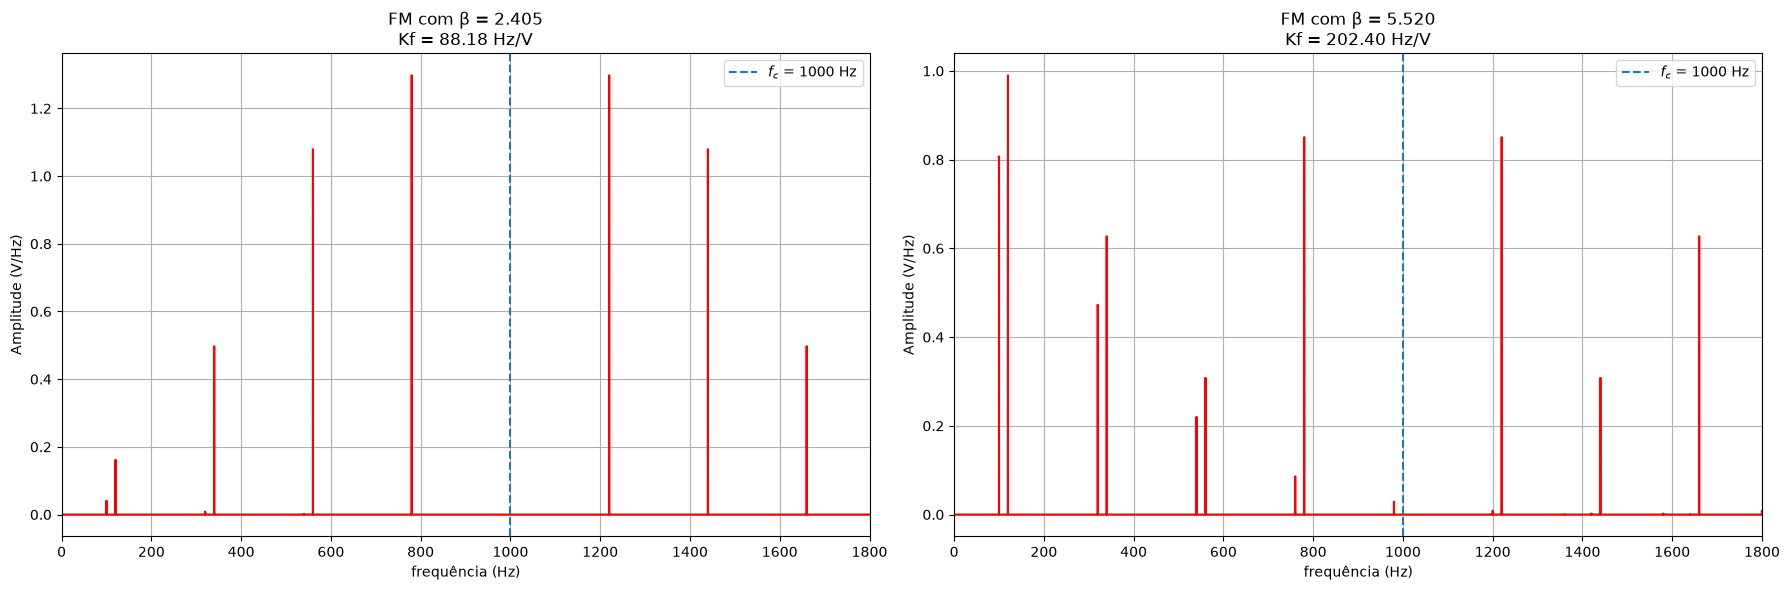

In [22]:
# ============================================================
# Comparação dos espectros
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


# ============================================================
# Caso 1
# ============================================================

axes[0].plot(freqs1, S1, 'r')

axes[0].axvline(
    fc,
    linestyle='--',
    label=f'$f_c$ = {fc} Hz'
)

axes[0].set_xlim([0, 1800])

axes[0].set_xlabel('frequência (Hz)')
axes[0].set_ylabel('Amplitude (V/Hz)')

axes[0].set_title(
    f'FM com β = {B1:.3f}\n'
    f'Kf = {Kf1:.2f} Hz/V'
)

axes[0].grid()
axes[0].legend()


# ============================================================
# Caso 2
# ============================================================

axes[1].plot(freqs2, S2, 'r')

axes[1].axvline(
    fc,
    linestyle='--',
    label=f'$f_c$ = {fc} Hz'
)

axes[1].set_xlim([0, 1800])

axes[1].set_xlabel('frequência (Hz)')
axes[1].set_ylabel('Amplitude (V/Hz)')

axes[1].set_title(
    f'FM com β = {B2:.3f}\n'
    f'Kf = {Kf2:.2f} Hz/V'
)

axes[1].grid()
axes[1].legend()


plt.tight_layout()
plt.show()

_fc basicamente disaparece em ambos os casos. Mas isso não significa que a informação desapareceu, pois ela ainda é carregada e distribuída nas bandas laterias._

_Podemos observar isso no gráfico acima, onde temos componentes em ~780Hz, ~1220Hz, ~340Hz, ~1660Hz e assim vai._

**3) Faixa estreita vs. faixa larga**

Repita a simulação com um Kf bem menor (por exemplo, resultando em β ≤ 0,2), mantendo Am e fm fixos. Compare visualmente o número de pares de bandas laterais com o caso de banda larga da Parte 1. Isso é consistente com o gráfico "Banda do sinal FM x Índice de Modulação" da Aula 3?

In [23]:
# ============================================================
# Parâmetros fixos
# ============================================================

Am = 6
fm = 220

Ac = 5
fc = 1000

# Caso de faixa larga
Kf_L = 172
B_L = Kf_L * Am / fm
Delta_f_L = Kf_L * Am

# Caso de faixa estreita
B_E = 0.2
Kf_E = B_E * fm / Am
Delta_f_E = Kf_E * Am


print("Faixa larga:")
print(f"Kf = {Kf_L:.2f} Hz/V")
print(f"β = {B_L:.2f}")
print(f"Δf = {Delta_f_L:.2f} Hz")

print("\nFaixa estreita:")
print(f"Kf = {Kf_E:.2f} Hz/V")
print(f"β = {B_E:.2f}")
print(f"Δf = {Delta_f_E:.2f} Hz")


# ============================================================
# Sinais no tempo
# ============================================================

Tstart = 0
Tstop = 4/fm
Tstep = 0.0001/fm

t = np.arange(Tstart, Tstop, Tstep)


# Faixa larga
st_L = Ac * np.cos(
    2*np.pi*fc*t +
    B_L*np.sin(2*np.pi*fm*t)
)


# Faixa estreita
st_E = Ac * np.cos(
    2*np.pi*fc*t +
    B_E*np.sin(2*np.pi*fm*t)
)

Faixa larga:
Kf = 172.00 Hz/V
β = 4.69
Δf = 1032.00 Hz

Faixa estreita:
Kf = 7.33 Hz/V
β = 0.20
Δf = 44.00 Hz


In [24]:
# ============================================================
# Janela para FFT
# ============================================================

Tstart_fft = 0
Tstop_fft = 10000/fc
Tstep_fft = 0.2/fc

t_fft = np.arange(Tstart_fft, Tstop_fft, Tstep_fft)

N = len(t_fft)


# ============================================================
# Sinal FM - faixa larga
# ============================================================

st_L_fft = Ac * np.cos(
    2*np.pi*fc*t_fft +
    B_L*np.sin(2*np.pi*fm*t_fft)
)

Sf_L = np.abs(np.fft.fft(st_L_fft))

freqs_L = np.fft.fftfreq(N, Tstep_fft)

idx_L = np.argsort(freqs_L)

freqs_L = freqs_L[idx_L]
Sf_L = Sf_L[idx_L] / N


# ============================================================
# Sinal FM - faixa estreita
# ============================================================

st_E_fft = Ac * np.cos(
    2*np.pi*fc*t_fft +
    B_E*np.sin(2*np.pi*fm*t_fft)
)

Sf_E = np.abs(np.fft.fft(st_E_fft))

freqs_E = np.fft.fftfreq(N, Tstep_fft)

idx_E = np.argsort(freqs_E)

freqs_E = freqs_E[idx_E]
Sf_E = Sf_E[idx_E] / N

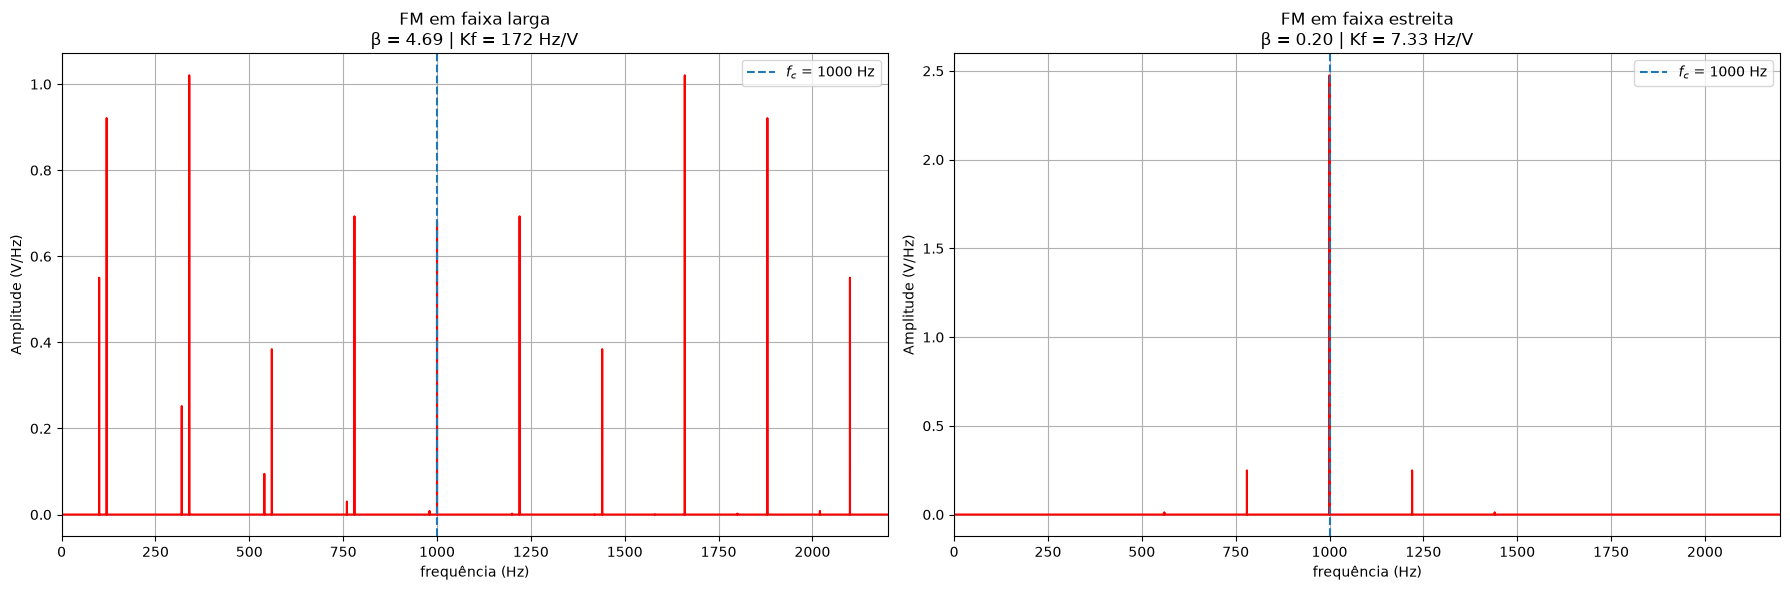

In [25]:
# ============================================================
# Comparação: faixa larga x faixa estreita
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


# ============================================================
# Faixa larga
# ============================================================

axes[0].plot(freqs_L, Sf_L, 'r')

axes[0].axvline(
    fc,
    linestyle='--',
    label=f'$f_c$ = {fc} Hz'
)

axes[0].set_xlim([0, 2200])

axes[0].set_xlabel('frequência (Hz)')
axes[0].set_ylabel('Amplitude (V/Hz)')

axes[0].set_title(
    f'FM em faixa larga\n'
    f'β = {B_L:.2f} | Kf = {Kf_L} Hz/V'
)

axes[0].grid()
axes[0].legend()


# ============================================================
# Faixa estreita
# ============================================================

axes[1].plot(freqs_E, Sf_E, 'r')

axes[1].axvline(
    fc,
    linestyle='--',
    label=f'$f_c$ = {fc} Hz'
)

axes[1].set_xlim([0, 2200])

axes[1].set_xlabel('frequência (Hz)')
axes[1].set_ylabel('Amplitude (V/Hz)')

axes[1].set_title(
    f'FM em faixa estreita\n'
    f'β = {B_E:.2f} | Kf = {Kf_E:.2f} Hz/V'
)

axes[1].grid()
axes[1].legend()


plt.tight_layout()
plt.show()

Sim, podemos observar que quando maior o indice de modulação, maior o número de bandas laterias significativas.

# Parte 3 — IA como auditora: encontre o bug

A célula de código abaixo tem **um erro proposital** na fórmula do índice de modulação. O código roda sem erros e produz um gráfico — mas o resultado não é fisicamente consistente com a teoria da Aula 3.

**Sua tarefa:**
1. Rode a célula e observe o espectro gerado.
2. Use uma IA (Claude, ChatGPT, etc.) como *auditora*: peça para ela **analisar o código linha a linha e apontar inconsistências com a teoria**, em vez de simplesmente pedir para "corrigir o código".
3. Identifique a linha exata do erro e explique, **usando a fórmula correta da Aula 3**, por que o β calculado está errado e como isso se manifesta no gráfico (ex: banda maior/menor do que deveria, tendência invertida ao variar fm, etc.).
4. Só depois de identificar e explicar o erro, corrija o código e confirme que o espectro agora bate com o esperado.



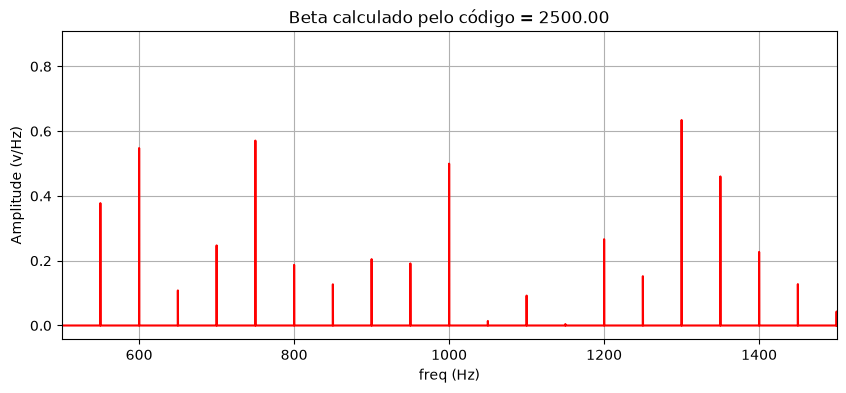

Beta calculado = 2500.00


In [26]:
# Código com um bug proposital — não é o mesmo exemplo da aula!

Am_bug = 4       # amplitude do sinal de info
fm_bug = 50      # frequência do sinal de info
Ac_bug = 5       # amplitude da portadora
fc_bug = 1000    # frequência da portadora
Kf_bug = 200     # sensibilidade do modulador

Tstart = 0
Tstop = 10000/fc_bug
Tstep = 0.2/fc_bug
t_bug = np.arange(Tstart, Tstop, Tstep)
N_bug = len(t_bug)

mt_bug = Am_bug*np.cos(2*math.pi*fm_bug*t_bug)
ct_bug = Ac_bug*np.cos(2*math.pi*fc_bug*t_bug)

B_bug = Kf_bug*fm_bug/Am_bug   # <-- fórmula usada aqui
st_bug = Ac_bug*np.cos(2*math.pi*fc_bug*t_bug + B_bug*np.sin(2*math.pi*fm_bug*t_bug))

Sf_bug = np.abs(np.fft.fft(st_bug))
freqs_bug = np.fft.fftfreq(st_bug.size, Tstep)
idx = np.argsort(freqs_bug)
freqs_bug = freqs_bug[idx]
Sf_bug = Sf_bug[idx]/N_bug

plt.figure(figsize=(10,4))
plt.plot(freqs_bug, Sf_bug, 'r')
plt.xlim([fc_bug-10*fm_bug, fc_bug+10*fm_bug])
plt.xlabel('freq (Hz)')
plt.ylabel('Amplitude (v/Hz)')
plt.title(f'Beta calculado pelo código = {B_bug:.2f}')
plt.grid()
plt.show()

print(f"Beta calculado = {B_bug:.2f}")

A linha é essa

B_bug = Kf_bug*fm_bug/Am_bug

que é basicamente o inverso da teoria.

Isso resulta em um beta enorme, que ocasiona em uma banda muito mais larga que o esperado.

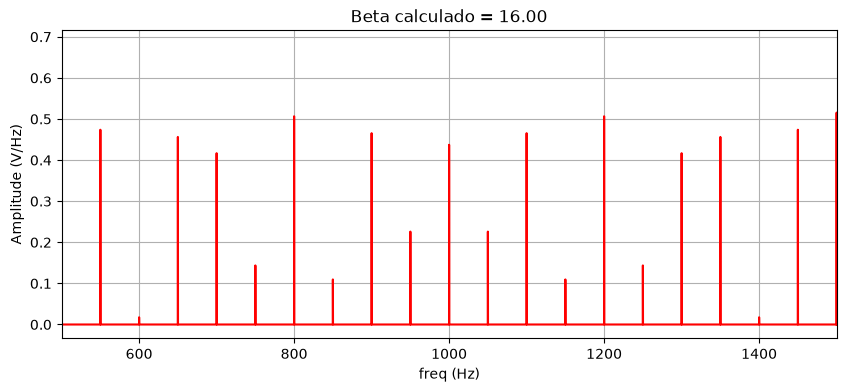

Beta calculado = 16.00


In [27]:
# ============================================================
# Parâmetros do sinal FM
# ============================================================

Am = 4          # amplitude do sinal de informação (V)
fm = 50         # frequência do sinal de informação (Hz)

Ac = 5          # amplitude da portadora (V)
fc = 1000       # frequência da portadora (Hz)

Kf = 200        # sensibilidade do modulador (Hz/V)


# ============================================================
# Geração dos sinais
# ============================================================

Tstart = 0

Tstop = 10000/fc

Tstep = 0.2/fc

t = np.arange(Tstart, Tstop, Tstep)

N = len(t)


# Sinal de informação
mt = Am*np.cos(2*math.pi*fm*t)


# Portadora
ct = Ac*np.cos(2*math.pi*fc*t)


# Índice de modulação FM
B = Kf*Am/fm


# Sinal FM
st = Ac*np.cos(
    2*math.pi*fc*t +
    B*np.sin(2*math.pi*fm*t)
)


# ============================================================
# FFT do sinal FM
# ============================================================

Sf = np.abs(np.fft.fft(st))

freqs = np.fft.fftfreq(st.size, Tstep)

idx = np.argsort(freqs)

freqs = freqs[idx]

Sf = Sf[idx]/N


# ============================================================
# Plot do espectro
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(freqs, Sf, 'r')

plt.xlim([
    fc - 10*fm,
    fc + 10*fm
])

plt.xlabel('freq (Hz)')

plt.ylabel('Amplitude (V/Hz)')

plt.title(f'Beta calculado = {B:.2f}')

plt.grid()

plt.show()


# ============================================================
# Resultados
# ============================================================

print(f"Beta calculado = {B:.2f}")

# Parte 4 — Comparando com um espectro real de FM comercial

Escolha uma estação de rádio FM comercial e obtenha um espectro real da transmissão dela, usando **um** dos métodos abaixo:

- Um WebSDR público (ex: websdr.org) sintonizado na estação escolhida, com print da tela mostrando a banda ocupada;
- Um arquivo de captura IQ de exemplo (bfm.zip);


**Sua tarefa:**
1. Anote a frequência central (fc) da estação escolhida e meça, visualmente pelo espectro, a largura de banda aproximada ocupada pelo sinal.
2. Usando os valores máximos definidos pela FCC para radiodifusão em FM (Aula 3, slide "Valores práticos": Δf = 75 kHz, fm = 15 kHz), calcule a largura de banda de Carson prevista.
3. Compare o valor medido com o valor previsto. Eles batem? Se houver diferença significativa, o que pode explicá-la (ex: a estação pode não estar usando o desvio máximo, resolução do espectro exibido, ruído, etc.)?

Inclua o print/imagem do espectro capturado como evidência.

In [28]:
# ============================================================
# Dados obtidos experimentalmente pelo espectro
# ============================================================

fc = 107.9e6          # frequência central da estação (Hz)

f_min = 107.82e6      # limite inferior aproximado (Hz)
f_max = 108.01e6      # limite superior aproximado (Hz)

B_medida = f_max - f_min


print("Medição experimental:")
print(f"Frequência central: {fc/1e6:.2f} MHz")
print(f"Limite inferior:    {f_min/1e6:.2f} MHz")
print(f"Limite superior:    {f_max/1e6:.2f} MHz")
print(f"Largura de banda:   {B_medida/1e3:.0f} kHz")

Medição experimental:
Frequência central: 107.90 MHz
Limite inferior:    107.82 MHz
Limite superior:    108.01 MHz
Largura de banda:   190 kHz


![imagem](image.png)
![imagem2](image_2.png)

In [29]:
# ============================================================
# Regra de Carson
# ============================================================

Delta_f = 75e3       # desvio máximo de frequência (Hz)
fm = 15e3            # frequência máxima da informação (Hz)

B_Carson = 2 * (Delta_f + fm)


print("Previsão pela regra de Carson:")
print(f"Δf = {Delta_f/1e3:.0f} kHz")
print(f"fm = {fm/1e3:.0f} kHz")
print(f"B_Carson = {B_Carson/1e3:.0f} kHz")

Previsão pela regra de Carson:
Δf = 75 kHz
fm = 15 kHz
B_Carson = 180 kHz


In [30]:
# ============================================================
# Comparação entre medida e teoria
# ============================================================

diferenca = B_medida - B_Carson

erro_percentual = abs(diferenca) / B_Carson * 100


print("Comparação:")
print(f"Largura medida:      {B_medida/1e3:.0f} kHz")
print(f"Largura de Carson:   {B_Carson/1e3:.0f} kHz")
print(f"Diferença:            {diferenca/1e3:.0f} kHz")
print(f"Diferença percentual: {erro_percentual:.1f}%")

Comparação:
Largura medida:      190 kHz
Largura de Carson:   180 kHz
Diferença:            10 kHz
Diferença percentual: 5.6%


# Log de uso de IA

Preencha um breve resumo do uso de IA nesta atividade (tratado como citação de fonte, não como delação):

- **Prompts utilizados** (resumo, não precisa ser literal):
- **O que a IA sugeriu / ajudou a encontrar**:
- **O que você teve que corrigir, adaptar ou verificar por conta própria**:

"só tem que ajustar o tempo total das células de tempo, pois com 10 segundos é impossível ver qualquer onda"

"Pelo grafico, a sensação que eu tenho é que talvez a sensibilidade ou a tensão do sinal de informação estão altos demais, gerando uma onda FM com formato irregular"

"mas isso é correto? A frequencia dar negativa"

"Certo. A próxima coisa que eu gostaria de testar é fazer uma célula que dobre fm e ajustar kf para manter Δf constante e verificar o que acontece com beta, e a largura de carson.

Depois verificar se esse é o mesmo comportamento que dobrar o Δf mantendo o fm fixo. Plotar os graficos lado a lado para verificar se diferem"

"Agora refazer usando um beta de 0,2. A ideia é verificar a largura da banda e a diferença dos dois casos"

"Ok, agora algo diferente.

O código que vou mandar tem um erro. Eu não quero que você corrija ele ainda. Quero que você encontre o erro e me diga qual o erro em relação a teoria."